## Análisis de datos II - Clase 7
---
### Asimetría de la target

Ejemplo: entrenar el mismo sobre una target asimétrica de tres formas:

1. Sin transformar, con error cuadrático (la opción por defecto).
2. Con transf. log. en la target.
3. Sin transformar, con pérdida Gamma.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import median_absolute_error, mean_absolute_error

### 1. Datos
Generamos un dataset con 5 features y una target que es el gasto mensual de 20.000 clientes.

Skewness de la target: 19.32


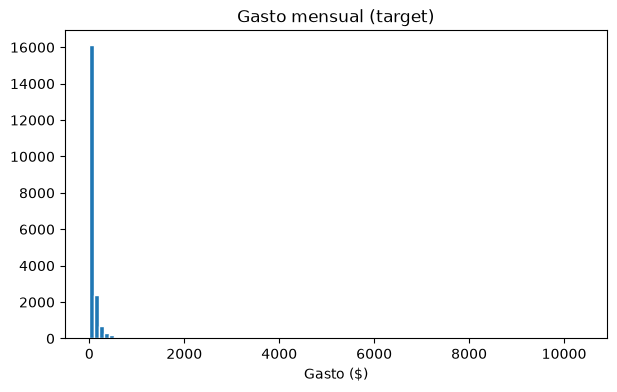

In [2]:
rng = np.random.default_rng(42)
n = 20000
X = rng.normal(size=(n, 5)) # Generamos 5 features aleatorios

# Gasto esperado según las características del cliente
media_esperada = 50 * np.exp(0.6 * X[:, 0] + 0.4 * X[:, 1] - 0.5 * X[:, 2] + 0.3 * X[:, 0] * X[:, 1])

# Gasto real: varía alrededor de esa media (positivo y asimétrico)
y = rng.gamma(shape=4, scale=media_esperada / 4)

print(f"Skewness de la target: {skew(y):.2f}")

plt.figure(figsize=(7, 4))
plt.hist(y, bins=100, edgecolor="white")
plt.title("Gasto mensual (target)")
plt.xlabel("Gasto ($)")
plt.show()

### 2. Entrenamiento de los tres modelos

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

params = dict(max_iter=300, learning_rate=0.05, random_state=42)

 
modelos = {
    "Sin transformar": HistGradientBoostingRegressor(**params),
    "Log": TransformedTargetRegressor(
        regressor=HistGradientBoostingRegressor(**params),
        func=np.log, inverse_func=np.exp), 
    "Pérdida Gamma": HistGradientBoostingRegressor(loss="gamma", **params),
}

predicciones = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    predicciones[nombre] = modelo.predict(X_test)

### 3. Predicción vs. valor real

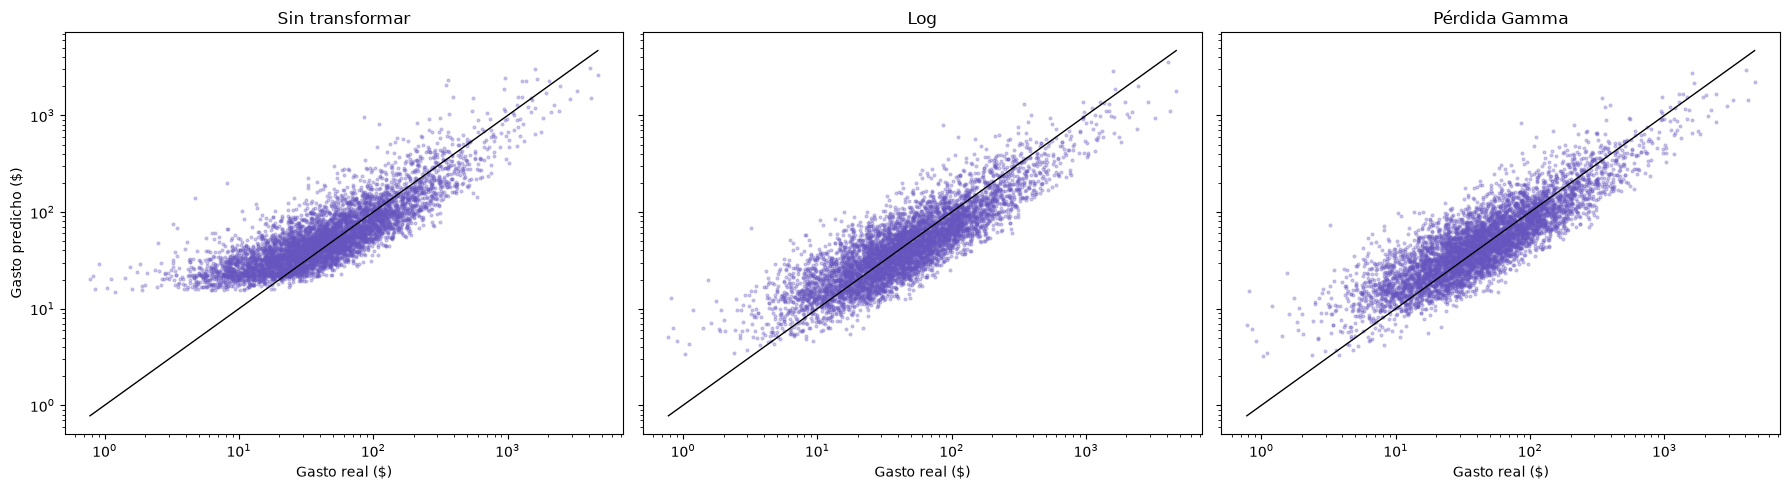

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
for ax, (nombre, pred) in zip(axes, predicciones.items()):
    ax.scatter(y_test, pred, s=4, alpha=0.3, color="#6655BE")
    lim = [y_test.min(), y_test.max()]
    ax.plot(lim, lim, color="black", linewidth=1)   # predicción perfecta
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_title(nombre)
    ax.set_xlabel("Gasto real ($)")
axes[0].set_ylabel("Gasto predicho ($)")
plt.tight_layout()
plt.show()

El modelo sin transformar casi nunca predice gastos menores a ~$20, aunque muchos clientes gastan menos: el error cuadrático lo hace enfocarse en los valores grandes. Con log y con pérdida Gamma, las predicciones siguen mejor la línea en todo el rango.


### 4. Comparación de los errores de predicción

In [5]:
top10 = y_test >= np.quantile(y_test, 0.9)

resultados = pd.DataFrame({
    nombre: {
        "Error con un cliente típico (mediana)": median_absolute_error(y_test, pred),
        "Error en el 10% que más gasta (MAE)": mean_absolute_error(y_test[top10], pred[top10]),
    }
    for nombre, pred in predicciones.items()
}).round(2)
resultados

,Sin transformar,Log,Pérdida Gamma
Error con un cliente típico (mediana),16.48,14.00,14.41
Error en el 10% que más gasta (MAE),175.00,171.73,164.07


Conclusiones:
- Con Log y Gamma el modelo da mejores resultados con los clientes típicos.
- Gamma es el que mejor predice a los clientes que más gastan.
- Cambiar la función de pérdida logra un efecto parecido a transformar, sin tener que transformar ni antitransformar la target.